# Анализ базы данных отдела продаж

# Описание исследования

В нашем распроряжении база данных компании.

# Цель исследования
 
Проанализировать базу данных, сделать выводы и дать рекомендации отделу продаж.

# Задачи исследования

1. Подключиться к базе данных.
2. Оценить представленные данные.
3. Выполнить соответствующие запросы.
4. Написать выводы по итогу выполнения каждого запроса.

# Исходные данные

Таблица departments содержит данные об отделах:

    department_id - SERIAL - идентификатор отдела;
    department_name - VARCHAR(50) - Название отдела (например, "Sales").
    
Таблица employees содержит данные об сотрудниках:
    
    employee_id - SERIAL - идентификатор сотрудника;
    first_name - VARCHAR(50) - имя сотрудника;
    last_name - VARCHAR(50) - фамилия сотрудника;
    email - VARCHAR(100) - email сотрудника;
    hire_date - DATE - дата приема на работу;
    department_id - INT - идентификатор отдела;
    salary - NUMERIC(10,2) - зарплата сотрудника.

Таблица sales содержит данные о продажах

    sale_id - SERIAL - идентификатор продажи
    employee_id - INT - идентификатор сотрудника;
    sale_date - DATE - дата продажи;
    amount - NUMERIC(10,2) - cумма продажи


## Подготовка к подключению к базе данных

### Импортируем нужные библиотеки

In [1]:
import pandas as pd
import sqlalchemy
from sqlalchemy import create_engine, text
from IPython.display import display, HTML, Image
import base64

### Устанавливаем параметры

In [2]:
DB_NAME = "test_db"
DB_USER = "postgres"
DB_PASSWORD = "{password}"
DB_HOST = "localhost"
DB_PORT = "5432"
connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

### Сохраняем коннектор

In [3]:
engine = create_engine(connection_string)

### Проверяем подключение

In [4]:
try:
    print("Успешное подключение к PostgreSQL!")

    # Пример запроса: список таблиц в базе
    tables = pd.read_sql(
        "SELECT table_name FROM information_schema.tables WHERE table_schema='public'", engine)
    print("\nДоступные таблицы в базе данных:")
    display(tables)

except Exception as e:
    print(f"Ошибка подключения: {e}")

Успешное подключение к PostgreSQL!

Доступные таблицы в базе данных:


,table_name
0,departments
1,employees
2,sales


## Исследовательский анализ данных

### Отобразим схему базы данных для исследования


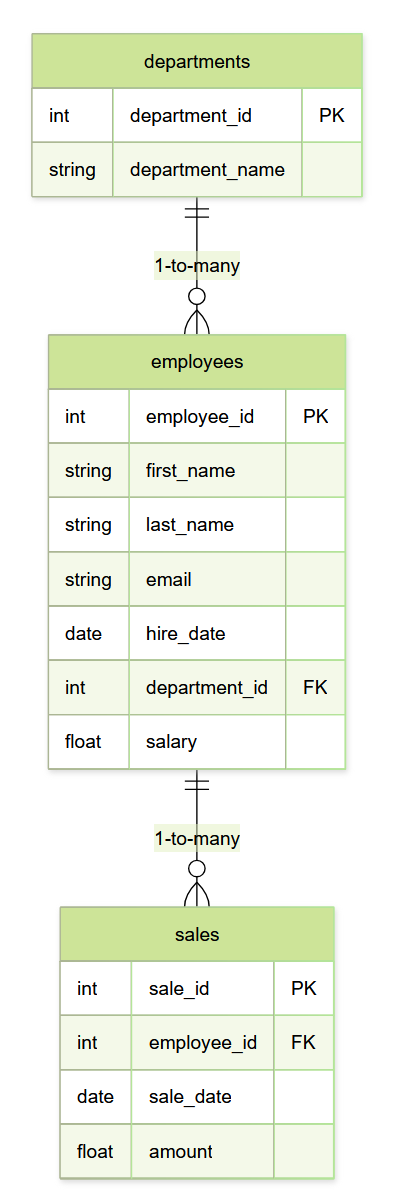

In [5]:
with open(r'D:\Аналитик данных\Тестовая база данных\Схема БД.png', 'rb') as f:
    data = f.read()
data_url = "data:image/png;base64," + base64.b64encode(data).decode()

display(HTML(f'''
    <div style="text-align:center;">
        <img src="{data_url}" width="300" height="300">
    </div>
'''))

### Выведем таблицы из базы данных

In [23]:
query = """
        SELECT *
        FROM departments
        """
df = pd.read_sql(query, engine)
display(df)

,department_id,department_name
0,1,Sales
1,2,Marketing
2,3,IT
3,4,Finance
4,5,HR


In [24]:
query = """
        SELECT *
        FROM employees
        """
df = pd.read_sql(query, engine)
display(df)

,employee_id,first_name,last_name,email,hire_date,department_id,salary
0,1,John,Doe,john.doe@example.com,2020-01-15,1,50000.0
1,2,Jane,Smith,jane.smith@example.com,2019-05-20,2,60000.0
2,3,Mike,Johnson,mike.johnson@example.com,2021-03-10,1,55000.0
3,4,Emily,Brown,emily.brown@example.com,2018-11-30,3,70000.0
4,5,David,Wilson,david.wilson@example.com,2022-02-05,4,65000.0


In [25]:
query = """
        SELECT *
        FROM sales
        """
df = pd.read_sql(query, engine)
display(df)

,sale_id,employee_id,sale_date,amount
0,1,1,2023-01-10,1500.0
1,2,1,2023-02-15,2000.0
2,3,2,2023-01-05,1000.0
3,4,3,2023-03-20,2500.0
4,5,3,2023-04-12,1800.0
5,6,4,2023-05-01,3000.0
6,7,5,2023-06-10,1200.0


### Задание 1: Вывести всех сотрудников из отдела "Sales"

In [7]:
query = """
        SELECT *
        FROM employees
        WHERE department_id = (SELECT department_id
                               FROM departments
					           WHERE department_name = 'Sales')
       """
df = pd.read_sql(query, engine)
display(df)

,employee_id,first_name,last_name,email,hire_date,department_id,salary
0,1,John,Doe,john.doe@example.com,2020-01-15,1,50000.0
1,3,Mike,Johnson,mike.johnson@example.com,2021-03-10,1,55000.0


### Задание 2: Найти общее количество продаж

In [8]:
query = """
        SELECT COUNT(*) as total_sales
        FROM sales
        """
df = pd.read_sql(query, engine)
display(df)

,total_sales
0,7


### Задание 3: Показать сотрудников, принятых на работу после 1 января 2020 года

In [9]:
query = """
        SELECT *
        FROM employees
        WHERE hire_date > '2020-01-01'
        """
df = pd.read_sql(query, engine)
display(df)

,employee_id,first_name,last_name,email,hire_date,department_id,salary
0,1,John,Doe,john.doe@example.com,2020-01-15,1,50000.0
1,3,Mike,Johnson,mike.johnson@example.com,2021-03-10,1,55000.0
2,5,David,Wilson,david.wilson@example.com,2022-02-05,4,65000.0


### Задание 4: Посчитать среднюю зарплату по каждому отделу

In [10]:
query = """
        SELECT d.department_name,
               ROUND(AVG(e.salary), 2) as avg_salary
        FROM employees as e
        JOIN departments as d ON e.department_id = d.department_id
        GROUP BY d.department_name
        ORDER BY avg_salary DESC;
        """
df = pd.read_sql(query, engine)
display(df)

,department_name,avg_salary
0,IT,70000.0
1,Finance,65000.0
2,Marketing,60000.0
3,Sales,52500.0


### Задание 4.1: Посчитать среднюю зарплату по каждому отделу, учитывать только сотрудников, принятых после 2020 года. Необходимо выводить только отделы со средней зарплатой выше 50 000. Добавить колонку с количеством сотрудников в каждом отделе. Отсортировать по убыванию средней зарплаты.

In [11]:
query = """
        SELECT d.department_name,
               ROUND(AVG(e.salary), 2) as avg_salary,
	           COUNT(e.employee_id) as employee_count
        FROM employees as e
        JOIN departments as d ON e.department_id = d.department_id
        WHERE EXTRACT(YEAR FROM e.hire_date) > 2020
        GROUP BY d.department_name
        HAVING AVG(e.salary) > 50000
        ORDER BY avg_salary DESC;
        """
df = pd.read_sql(query, engine)
display(df)

,department_name,avg_salary,employee_count
0,Finance,65000.0,1
1,Sales,55000.0,1


### Задание 5. Найти топ-3 сотрудников с наибольшей суммой продаж

In [12]:
query = """
        WITH top_sellers AS (SELECT employee_id, SUM(amount) as sum_amount
                             FROM sales
                             GROUP BY employee_id
                             ORDER BY sum_amount DESC
                             LIMIT 3)
        SELECT e.first_name,
               e.last_name,
               t.sum_amount
        FROM employees AS e
        JOIN top_sellers as t ON e.employee_id = t.employee_id
        ORDER BY sum_amount DESC
        """
df = pd.read_sql(query, engine)
display(df)

,first_name,last_name,sum_amount
0,Mike,Johnson,4300.0
1,John,Doe,3500.0
2,Emily,Brown,3000.0


### Задание 6. Вывести отделы, где средняя зарплата превышает 55000

In [13]:
query = """
        SELECT d.department_name,
               ROUND(AVG(e.salary), 2) as avg_salary
        FROM employees as e
        JOIN departments as d ON e.department_id = d.department_id
        GROUP BY d.department_name
        HAVING AVG(e.salary) > 55000
        ORDER BY avg_salary DESC
        """
df = pd.read_sql(query, engine)
display(df)

,department_name,avg_salary
0,IT,70000.0
1,Finance,65000.0
2,Marketing,60000.0


### Задание 7. Найти сотрудников, не совершавших ни одной продажи

In [14]:
query = """
        SELECT first_name, last_name
        FROM employees
        WHERE employee_id NOT IN (SELECT employee_id
                                  FROM sales);
        """
df = pd.read_sql(query, engine)
display(df)

,first_name,last_name


### Задание 8. Вывести отделы, где ни один сотрудник не совершал продаж

In [15]:
query = """
        SELECT department_name
        FROM departments
        WHERE department_id NOT IN (SELECT DISTINCT(e.department_id)
                                    FROM employees as e
                                    INNER JOIN sales as s ON e.employee_id = s.employee_id);
        """
df = pd.read_sql(query, engine)
display(df)

,department_name
0,HR


In [16]:
query = """
        SELECT d.department_name
        FROM departments AS d
        WHERE NOT EXISTS (SELECT 1
                          FROM employees AS e
                          JOIN sales s ON e.employee_id = s.employee_id
                          WHERE e.department_id = d.department_id
        );
        """
df = pd.read_sql(query, engine)
display(df)

,department_name
0,HR


### Задание 9. Показать сумму продаж по месяцам за 2023 год

In [17]:
query = """
        SELECT EXTRACT(YEAR FROM sale_date) as year_of_sales,
               EXTRACT(MONTH FROM sale_date) as month_of_sales,
               SUM(amount) as total_amount
        FROM sales
        GROUP BY year_of_sales, month_of_sales 
        HAVING EXTRACT(YEAR FROM sale_date) = 2023
        """
df = pd.read_sql(query, engine)
df['year_of_sales'] = df['year_of_sales'].astype(int)
df['month_of_sales'] = df['month_of_sales'].astype(int)
display(df)

,year_of_sales,month_of_sales,total_amount
0,2023,1,2500.0
1,2023,2,2000.0
2,2023,3,2500.0
3,2023,4,1800.0
4,2023,5,3000.0
5,2023,6,1200.0


In [18]:
query = """
        SELECT EXTRACT(YEAR FROM sale_date) AS year_of_sales,
               EXTRACT(MONTH FROM sale_date) AS month_of_sales,
               SUM(amount) AS total_amount
        FROM sales
        WHERE EXTRACT(YEAR FROM sale_date) = 2023
        GROUP BY EXTRACT(YEAR FROM sale_date), EXTRACT(MONTH FROM sale_date)
        ORDER BY month_of_sales;
        """
df = pd.read_sql(query, engine)
df['year_of_sales'] = df['year_of_sales'].astype(int)
df['month_of_sales'] = df['month_of_sales'].astype(int)
display(df)

,year_of_sales,month_of_sales,total_amount
0,2023,1,2500.0
1,2023,2,2000.0
2,2023,3,2500.0
3,2023,4,1800.0
4,2023,5,3000.0
5,2023,6,1200.0


### Задание 10. Найти месяцы 2023 года с продажами выше среднемесячного значения

In [19]:
query = """
        WITH monthly_totals AS
       (SELECT EXTRACT(YEAR FROM sale_date) as year_of_sales,
               EXTRACT(MONTH FROM sale_date) as month_of_sales,
               SUM(amount) as total_amount
        FROM sales
        WHERE EXTRACT(YEAR FROM sale_date) = 2023
        GROUP BY year_of_sales, month_of_sales)
        SELECT year_of_sales,
               month_of_sales,
               total_amount
        FROM monthly_totals
        WHERE total_amount > (SELECT AVG(total_amount) FROM monthly_totals)
        ORDER BY total_amount DESC;
        """
df = pd.read_sql(query, engine)
df['year_of_sales'] = df['year_of_sales'].astype(int)
df['month_of_sales'] = df['month_of_sales'].astype(int)
display(df)

,year_of_sales,month_of_sales,total_amount
0,2023,5,3000.0
1,2023,1,2500.0
2,2023,3,2500.0


### Задание 11. Вывести сотрудников с зарплатой выше средней по их отделу

In [20]:
query = """
        SELECT department_name,
               first_name,
               last_name,
	           salary,
	           avg_dept_salary
       FROM (SELECT d.department_name,
                    e.first_name,
                    e.last_name,
                    e.salary,
                    AVG(e.salary) OVER (PARTITION BY d.department_name) as avg_dept_salary
             FROM departments as d
             INNER JOIN employees as e ON d.department_id = e.department_id
             ORDER BY avg_dept_salary DESC)
        WHERE salary > avg_dept_salary
        """
df = pd.read_sql(query, engine)
display(df)

,department_name,first_name,last_name,salary,avg_dept_salary
0,Sales,Mike,Johnson,55000.0,52500.0


In [21]:
query = """
        WITH dept_stats AS (
             SELECT d.department_name,
                    e.first_name,
                    e.last_name,
                    e.salary,
                    AVG(e.salary) OVER (PARTITION BY e.department_id) as avg_dept_salary
             FROM employees e
             JOIN departments d ON e.department_id = d.department_id)
       SELECT * FROM dept_stats
       WHERE salary > avg_dept_salary;
       """
df = pd.read_sql(query, engine)
display(df)

,department_name,first_name,last_name,salary,avg_dept_salary
0,Sales,Mike,Johnson,55000.0,52500.0


### Задание 12. Посчитать количество сотрудников, принятых на работу в каждом году

In [22]:
query = """
        SELECT EXTRACT(YEAR FROM hire_date) as hire_year,
               COUNT(employee_id) as count_employees
        FROM employees
        GROUP BY hire_year
        ORDER BY hire_year;
        """
df = pd.read_sql(query, engine)
df['hire_year'] = df['hire_year'].astype(int)
display(df)

,hire_year,count_employees
0,2018,1
1,2019,1
2,2020,1
3,2021,1
4,2022,1


### Задание 13: Увеличить зарплату на 10% всем сотрудникам отдела "IT"

In [26]:
with engine.connect() as conn:
    query = text("""
            UPDATE employees
            SET salary = salary * 1.10
            WHERE department_id = (SELECT department_id
                                   FROM departments
                                   WHERE department_name = 'IT');
            """)
    conn.execute(query)
    conn.commit()

#### Проверим изменения в столбце salary в таблице employees для сотрудников отдела "IT"

In [27]:
query = """
        SELECT * FROM employees
        WHERE department_id = (SELECT department_id
                                   FROM departments
                                   WHERE department_name = 'IT')
        """
df = pd.read_sql(query, engine)
display(df)

,employee_id,first_name,last_name,email,hire_date,department_id,salary
0,4,Emily,Brown,emily.brown@example.com,2018-11-30,3,77000.0


### Задание 14. Удалить все продажи, совершенные до февраля 2023 года

In [34]:
with engine.connect() as conn:
    query = text("""
                 DELETE FROM sales
                 WHERE sale_date < '2023-02-01';
            """)
    conn.execute(query)
    conn.commit()

#### Проверим изменения в столбце sale_date в таблице sales

In [35]:
query = """
        SELECT * FROM sales
        ORDER BY sale_date
        """
df = pd.read_sql(query, engine)
display(df)

,sale_id,employee_id,sale_date,amount
0,2,1,2023-02-15,2000.0
1,4,3,2023-03-20,2500.0
2,5,3,2023-04-12,1800.0
3,6,4,2023-05-01,3000.0
4,7,5,2023-06-10,1200.0


### Задание 15. Добавить нового сотрудника в отдел "HR" и сразу добавить для него одну продажу

In [36]:
with engine.connect() as conn:
    # Шаг 1: Добавляем сотрудника и получаем его ID
    insert_employee = text("""
        INSERT INTO employees (
            first_name, 
            last_name, 
            email, 
            hire_date, 
            department_id, 
            salary
        )
        VALUES (
            'Алексей', 
            'Петров', 
            'alex.petrov@example.com', 
            CURRENT_DATE, 
            (SELECT department_id FROM departments WHERE department_name = 'HR'), 
            55000
        )
        RETURNING employee_id;
    """)
    
    result = conn.execute(insert_employee)
    new_employee_id = result.scalar()  # Получаем ID нового сотрудника

    # Шаг 2: Добавляем продажу
    insert_sale = text("""
        INSERT INTO sales (employee_id, sale_date, amount)
        VALUES (:employee_id, CURRENT_DATE, 2500);
    """)
    
    conn.execute(insert_sale, {"employee_id": new_employee_id})
    conn.commit()

#### Проверяем наличие нового сотрудника в таблице employees

In [37]:
query = """
        SELECT * FROM employees 
        WHERE email = 'alex.petrov@example.com';
        """
df = pd.read_sql(query, engine)
display(df)

,employee_id,first_name,last_name,email,hire_date,department_id,salary
0,6,Алексей,Петров,alex.petrov@example.com,2025-07-18,5,55000.0


#### Проверяем продажи нового сотрудника в таблице sales

In [38]:
query = """
        SELECT * FROM sales 
        WHERE employee_id = (SELECT employee_id
                             FROM employees
                             WHERE email = 'alex.petrov@example.com');
        """
df = pd.read_sql(query, engine)
display(df)

,sale_id,employee_id,sale_date,amount
0,8,6,2025-07-18,2500.0


## Общие выводы

1. Структура отделов и сотрудников

    В компании представлено 5 отделов: Sales, Marketing, IT, Finance, HR.

    В отделе Sales работают 2 сотрудника (John Doe и Mike Johnson), что является минимальным количеством среди всех отделов.

    В отделе HR нет сотрудников, совершавших продажи, что может указывать на его непрямое участие в продажах или необходимость пересмотра его роли.

2. Эффективность продаж

    Всего зафиксировано 7 продаж.

    Топ-3 сотрудника по сумме продаж:

        Mike Johnson (Sales) — 4300.0

        John Doe (Sales) — 3500.0

        Emily Brown (IT) — 3000.0

    Mike Johnson демонстрирует наивысшую эффективность, что может служить примером для других сотрудников.

3. Заработная плата

    Средняя зарплата по отделам (по убыванию):

        IT — 70 000.0

        Finance — 65 000.0

        Marketing — 60 000.0

        Sales — 52 500.0

    Отдел Sales имеет наименьшую среднюю зарплату, несмотря на прямое участие в продажах. Это может негативно влиять на мотивацию сотрудников.

4. Динамика найма

    С 2020 года было принято 3 сотрудника:

        John Doe (Sales)

        Mike Johnson (Sales)

        David Wilson (Finance)

    Все новые сотрудники были приняты в отделы, связанные с продажами или финансами, что указывает на стратегический фокус компании.

5. Проблемные зоны

    Отсутствие продаж в отделе HR — возможно, это не является их прямой задачей, но стоит рассмотреть возможность их участия в продажах услуг или внутренних продуктах.

    Низкая средняя зарплата в отделе Sales — может требовать пересмотра системы мотивации.

    Не все сотрудники активны в продажах — например, Jane Smith (Marketing) имеет лишь одну продажу на 1000.0.

Рекомендации

    Мотивация отдела Sales:

        Пересмотреть систему оплаты труда, добавить бонусы за превышение плана.

        Внедрить программу обучения на основе опыта Mike Johnson.

    Активизация отдела Marketing:

        Увеличить вовлеченность в продажи, возможно, через кросс-функциональные проекты.

    Использование данных IT:

        Emily Brown показывает высокие результаты — её опыт можно использовать для обучения других сотрудников.

    Оптимизация HR:

        Рассмотреть возможность участия в продажах HR-услуг или продуктов.

        Провести аудит эффективности отдела.

    Общий мониторинг:

        Внедрить регулярный анализ продаж и KPI для каждого сотрудника.

        Использовать данные для планирования найма и бюджетирования.